# 7. Subplots y figuras múltiples
Profundizamos en la creación de diseños complejos con Matplotlib, aprovechando la API orientada a objetos dentro de proyectos desarrollados con Python.

Los ejemplos se apoyan en NumPy para generar datos y muestran cómo combinar subplots, ejes compartidos y `GridSpec`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 7.1 Uso de `subplot` y `subplots`
`plt.subplot` sigue el estilo imperativo clásico, mientras que `plt.subplots` devuelve la pareja `(fig, ax)` y simplifica el trabajo con la API moderna.

### Ejemplo básico con subplots

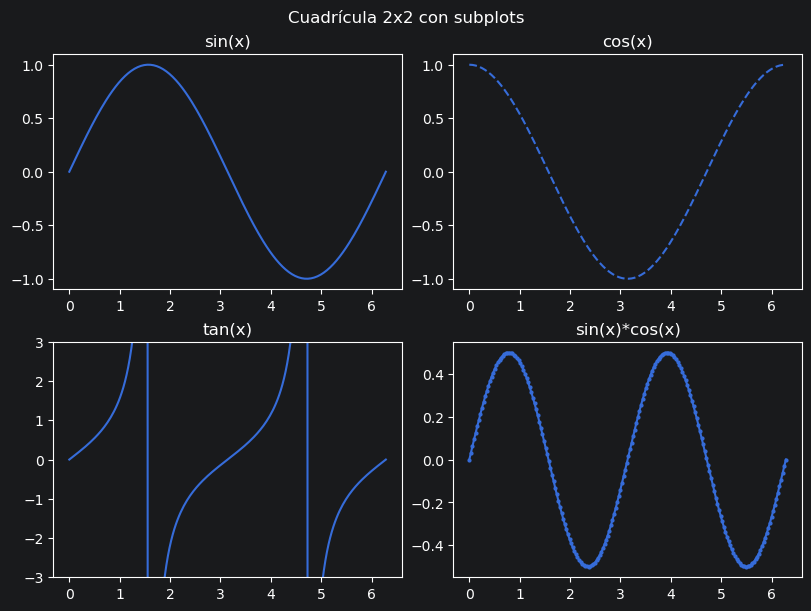

In [2]:
x = np.linspace(0, 2 * np.pi, 200)

# Sintaxis moderna: Figure y arreglo de Axes
fig, axs = plt.subplots(nrows=2,
                        ncols=2,
                        figsize=(8, 6),
                        layout='constrained')
# 'layout="constrained"' ayuda a evitar solapamientos de textos y etiquetas.

axs[0, 0].plot(x, np.sin(x))
axs[0, 0].set_title("sin(x)")

axs[0, 1].plot(x, np.cos(x), linestyle="--")
axs[0, 1].set_title("cos(x)")

axs[1, 0].plot(x, np.tan(x))
axs[1, 0].set_title("tan(x)")
axs[1, 0].set_ylim(-3, 3)  # Acotar tan(x)

axs[1, 1].plot(x, np.sin(x) * np.cos(x), marker="o", markersize=2, linestyle="-")
axs[1, 1].set_title("sin(x)*cos(x)")

fig.suptitle("Cuadrícula 2x2 con subplots", fontsize=12)
plt.show()

⚡ Preferimos `layout='constrained'` (o `constrained_layout=True`) para que Matplotlib gestione los márgenes.

* `fig, ax = plt.subplots()` devuelve un arreglo de `Axes` cuando `nrows * ncols > 1`
* Utilizamos `axes.flat` para iterar sobre todos los subplots con un solo bucle.

## 7.2 Compartir ejes `sharex`, `sharey`
Compartir ejes sincroniza límites, ticks y zoom/pan entre subplots, ideal para comparaciones en la misma escala.

### Compartir eje X

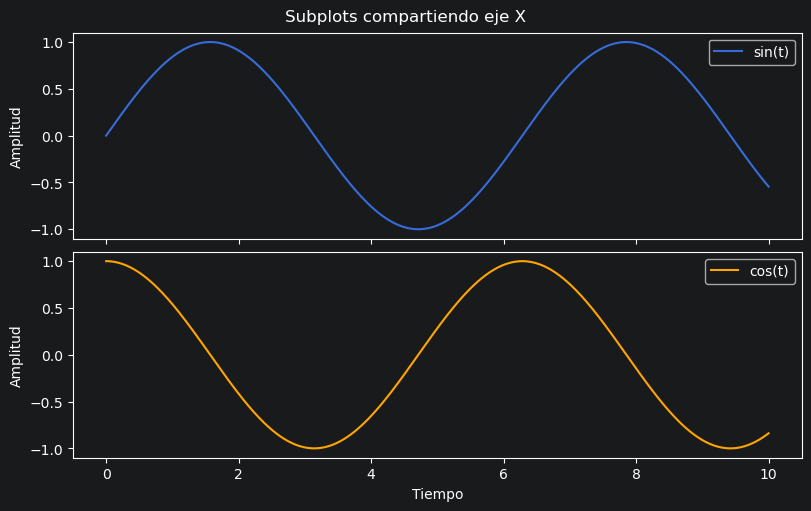

In [3]:
t = np.linspace(0, 10, 500)
s1 = np.sin(t)
s2 = np.cos(t)

fig, (ax1, ax2) = plt.subplots(2, 1,
                               sharex=True,
                               figsize=(8, 5),
                               layout='constrained')

ax1.plot(t, s1, label="sin(t)")
ax1.set_ylabel("Amplitud")
ax1.legend()

ax2.plot(t, s2, color="orange", label="cos(t)")
ax2.set_xlabel("Tiempo")
ax2.set_ylabel("Amplitud")
ax2.legend()

fig.suptitle("Subplots compartiendo eje X")
plt.show()

### Compartir eje Y

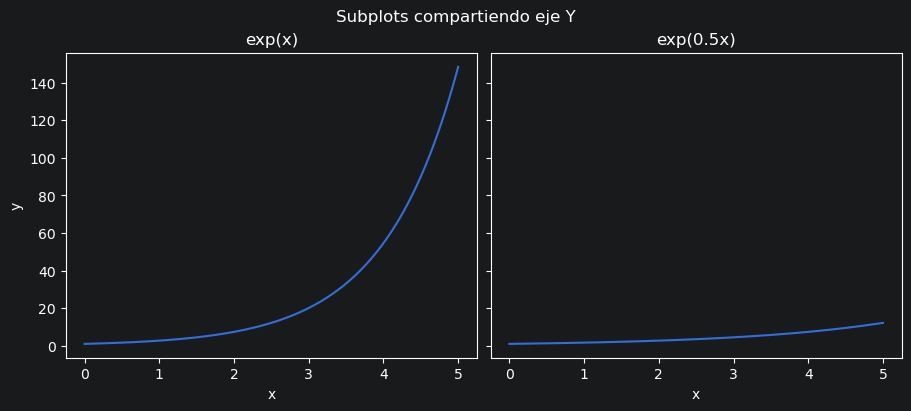

In [4]:
x = np.linspace(0, 5, 200)

fig, (ax1, ax2) = plt.subplots(1, 2,
                               sharey=True,
                               figsize=(9, 4),
                               layout='constrained')

ax1.plot(x, np.exp(x))
ax1.set_title("exp(x)")
ax1.set_xlabel("x")
ax1.set_ylabel("y")

ax2.plot(x, np.exp(0.5 * x))
ax2.set_title("exp(0.5x)")
ax2.set_xlabel("x")

fig.suptitle("Subplots compartiendo eje Y")
plt.show()

💡 Puedes combinar `sharex=True` y `sharey=True` para cuadrículas completas.

## 7.3 Diseño avanzado con `GridSpec`
`GridSpec` permite composiciones flexibles: celdas de distinto tamaño, subplots que abarcan varias filas/columnas y control de proporciones.

### Conceptos clave
* Definimos la grilla con `GridSpec(nrows, ncols)`
* Creamos ejes con `fig.add_subplot(gs[fila_ini:fila_fin, col_ini:col_fin])`
* Utilizamos `width_ratios` y `height_ratios` para ajustar proporciones.

In [5]:
from matplotlib.gridspec import GridSpec


### Ejemplo 1: Subplot grande + dos pequeños

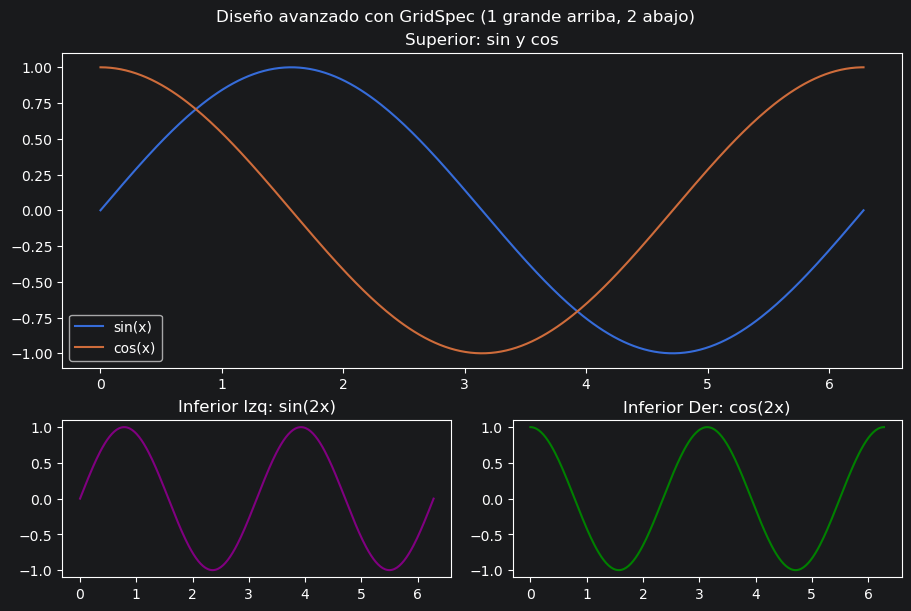

In [6]:
x = np.linspace(0, 2 * np.pi, 300)

fig = plt.figure(figsize=(9, 6), layout='constrained')
gs = GridSpec(nrows=2,
              ncols=2,
              figure=fig,
              height_ratios=[2, 1])

ax_top = fig.add_subplot(gs[0, :])
ax_top.plot(x, np.sin(x), label="sin(x)")
ax_top.plot(x, np.cos(x), label="cos(x)")
ax_top.set_title("Superior: sin y cos")
ax_top.legend()

ax_bl = fig.add_subplot(gs[1, 0])
ax_bl.plot(x, np.sin(2 * x), color="purple")
ax_bl.set_title("Inferior Izq: sin(2x)")

ax_br = fig.add_subplot(gs[1, 1])
ax_br.plot(x, np.cos(2 * x), color="green")
ax_br.set_title("Inferior Der: cos(2x)")

fig.suptitle("Diseño avanzado con GridSpec (1 grande arriba, 2 abajo)")
plt.show()

### Ejemplo 2: Columnas asimétricas y subplot que abarca filas

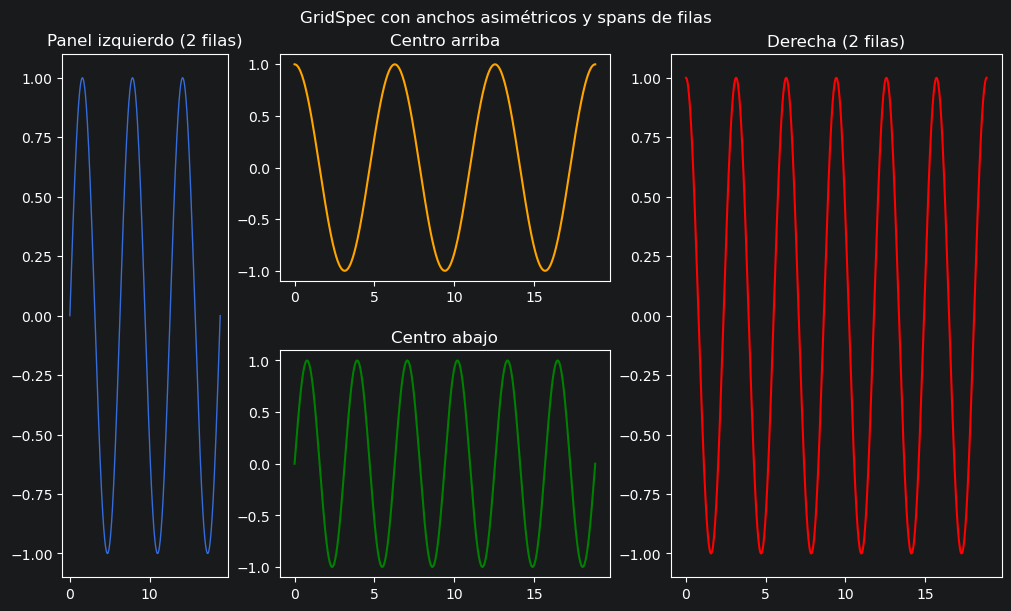

In [7]:
t = np.linspace(0, 6 * np.pi, 600)

fig = plt.figure(figsize=(10, 6), layout='constrained')
gs = GridSpec(nrows=2,
              ncols=3,
              figure=fig,
              width_ratios=[1, 2, 2],
              height_ratios=[1, 1])

ax_left = fig.add_subplot(gs[:, 0])
ax_left.plot(t, np.sin(t), linewidth=1)
ax_left.set_title("Panel izquierdo (2 filas)")

ax_c_top = fig.add_subplot(gs[0, 1])
ax_c_top.plot(t, np.cos(t), color="orange")
ax_c_top.set_title("Centro arriba")

ax_c_bot = fig.add_subplot(gs[1, 1])
ax_c_bot.plot(t, np.sin(2 * t), color="green")
ax_c_bot.set_title("Centro abajo")

ax_right = fig.add_subplot(gs[:, 2])
ax_right.plot(t, np.cos(2 * t), color="red")
ax_right.set_title("Derecha (2 filas)")

fig.suptitle("GridSpec con anchos asimétricos y spans de filas")
plt.show()

### Ejemplo 3: Compartir ejes dentro de GridSpec

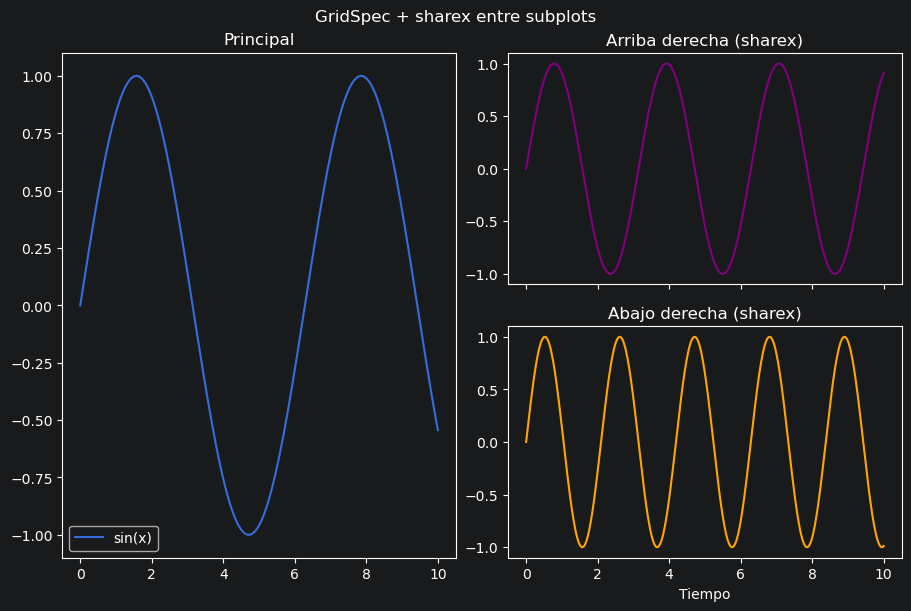

In [8]:
x = np.linspace(0, 10, 400)

fig = plt.figure(figsize=(9, 6), layout='constrained')
gs = GridSpec(2, 2, figure=fig)

ax_main = fig.add_subplot(gs[:, 0])
ax_tr = fig.add_subplot(gs[0, 1], sharex=ax_main)
ax_br = fig.add_subplot(gs[1, 1], sharex=ax_main)

ax_main.plot(x, np.sin(x), label="sin(x)")
ax_main.set_title("Principal")
ax_main.legend()

ax_tr.plot(x, np.sin(2 * x), color="purple")
ax_tr.set_title("Arriba derecha (sharex)")

ax_br.plot(x, np.sin(3 * x), color="orange")
ax_br.set_title("Abajo derecha (sharex)")
ax_br.set_xlabel("Tiempo")

plt.setp(ax_tr.get_xticklabels(), visible=False)

fig.suptitle("GridSpec + sharex entre subplots")
plt.show()

🔧 La clase `GridSpec` forma parte de `matplotlib.gridspec` y ofrece un control detallado sin abandonar la API OO.

## Buenas prácticas y checklist
* Utilizamos `plt.subplots` para cuadrículas regulares y `GridSpec` para diseños asimétricos
* Activamos `layout='constrained'` para evitar solapamientos de textos
* Compartimos ejes `sharex`, `sharey` cuando necesites comparar series en la misma escala
* Rotulamos cada subplot con `set_title`, `set_xlabel` y `set_ylabel`
* Añadimos un título global con `fig.suptitle` y ajustamos proporciones con `width_ratios` / `height_ratios` según sea necesario
* Ocultamos etiquetas redundantes en ejes compartidos con `plt.setp(..., visible=False)` para mejorar la lectura.